## Data Splitting

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv('../data/processed/train_cleaned.csv')

# 2. Split by engine units (20% for test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['unit']))

# 3. Create Train/Test sets
train_data = df.iloc[train_idx].copy()
test_data = df.iloc[test_idx].copy()

# IMPORTANT: Reset index immediately to align rows perfectly
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# 4. Create X and y
X_train = train_data.drop(['unit', 'RUL'], axis=1)
y_train = train_data['RUL']

X_test = test_data.drop(['unit', 'RUL'], axis=1)
y_test = test_data['RUL']

print(f" Step 1 OK: {test_data['unit'].nunique()} engines in Test set.")
print(f"Test data columns: {test_data.columns.tolist()}")

 Step 1 OK: 20 engines in Test set.
Test data columns: ['unit', 'cycle', 'os1', 'os2', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21', 'RUL']


## Advanced Feature Engineering

In [11]:
## Advanced Feature Engineering

# 1. Identify sensor columns
# Exclude 'unit' (ID), 'cycle' (Time), and 'RUL' (Target)
sensor_cols = [col for col in train_data.columns if col not in ['unit', 'cycle', 'RUL']]

# 2. Define temporal feature engineering function
def add_temporal_features(df, window_size=10):
    """
    Computes rolling mean and rolling standard deviation for each sensor.
    Groups by 'unit' to prevent data leakage between different engines.
    """
    df_out = df.copy()
    
    for col in sensor_cols:
        # Rolling Mean: Captures degradation trends
        df_out[f'{col}_roll_mean'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).mean()
        )
        
        # Rolling Std: Captures signal instability/vibrations
        df_out[f'{col}_roll_std'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window_size, min_periods=1).std().fillna(0)
        )
        
    return df_out

# 3. Apply engineering to Train and Test sets
# Note: Original train_data/test_data are used to maintain 'unit' column for grouping
train_data_eng = add_temporal_features(train_data, window_size=10)
test_data_eng = add_temporal_features(test_data, window_size=10)

# 4. Update X_train and X_test
# Drop identifiers and target, keeping 'cycle' and new features
X_train = train_data_eng.drop(['unit', 'RUL'], axis=1)
X_test = test_data_eng.drop(['unit', 'RUL'], axis=1)

print("--- FEATURE ENGINEERING SUMMARY ---")
print(f"Initial features count : {len(sensor_cols) + 1}") 
print(f"Final features count   : {X_train.shape[1]}")
print(f"New columns preview    : {[col for col in X_train.columns if 'roll' in col][:5]}")


--- FEATURE ENGINEERING SUMMARY ---
Initial features count : 20
Final features count   : 58
New columns preview    : ['os1_roll_mean', 'os1_roll_std', 'os2_roll_mean', 'os2_roll_std', 's2_roll_mean']


## Baseline Comparison

In [12]:
## Baseline Comparison

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Initialize and train the Simple Linear Regression model
baseline = LinearRegression()
baseline.fit(X_train, y_train)

# 2. Generate predictions on the test set
y_baseline = baseline.predict(X_test)

# 3. Calculate performance metrics
# RMSE is critical as it penalizes large errors more heavily
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_baseline))
# MAE gives the average error in terms of cycles
mae_baseline = mean_absolute_error(y_test, y_baseline)

print("--- BASELINE RESULTS (LINEAR REGRESSION) ---")
print(f"Baseline RMSE: {rmse_baseline:.2f} cycles")
print(f"Baseline MAE:  {mae_baseline:.2f} cycles")

# Optional: Quick check on the first 5 predictions vs actual values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_baseline})
print("Sample Predictions:")
print(comparison_df.head())

--- BASELINE RESULTS (LINEAR REGRESSION) ---
Baseline RMSE: 32.21 cycles
Baseline MAE:  25.67 cycles
Sample Predictions:
   Actual   Predicted
0     191  196.208458
1     190  162.958739
2     189  174.870214
3     188  183.289033
4     187  174.166624


## Hyperparameter Optimization (Optuna)

In [13]:
import optuna
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    # 1. Define the search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist' # Faster training
    }
    
    # 2. Setup GroupKFold cross-validation (5 folds)
    # This ensures we validate on 'unseen' engines within the training set
    gkf = GroupKFold(n_splits=5)
    
    model = xgb.XGBRegressor(**params)
    
    # 3. Calculate CV score using Negative RMSE
    # We use train_data['unit'] to maintain the group integrity
    scores = cross_val_score(
        model, X_train, y_train, 
        cv=gkf, 
        groups=train_data['unit'], 
        scoring='neg_root_mean_squared_error'
    )
    
    # Return the average RMSE (multiply by -1 because scoring is negative)
    return -scores.mean()

# 4. Run the study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=25) 

print("--- OPTUNA OPTIMIZATION COMPLETE ---")
print(f"Best CV RMSE: {study.best_value:.2f} cycles")
print(f"Best Parameters: {study.best_params}")

/home/pc/AI/projects/predictive_maintenance/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-06 21:36:31,596] A new study created in memory with name: no-name-9d180969-56a7-450a-b8d2-235b994d774b
[I 2026-04-06 21:42:33,210] Trial 0 finished with value: 42.04523849487305 and parameters: {'n_estimators': 1402, 'max_depth': 4, 'learning_rate': 0.022534249950924432, 'subsample': 0.8413366754007523, 'colsample_bytree': 0.6065727705896248}. Best is trial 0 with value: 42.04523849487305.
[I 2026-04-06 21:46:15,827] Trial 1 finished with value: 41.18433609008789 and parameters: {'n_estimators': 1224, 'max_depth': 5, 'learning_rate': 0.007713506983328117, 'subsample': 0.8601925320409793, 'colsample_bytree': 0.6031706297183891}. Best is trial 1 with value: 41.18433609008789.
[I 2026-04-06 21:50:23

--- OPTUNA OPTIMIZATION COMPLETE ---
Best CV RMSE: 39.72 cycles
Best Parameters: {'n_estimators': 798, 'max_depth': 3, 'learning_rate': 0.005078402587177554, 'subsample': 0.6237992710906719, 'colsample_bytree': 0.719294912388579}


## Model Training

In [14]:
import joblib

from sklearn.metrics import r2_score



# 1. On crée le modèle final avec les meilleurs paramètres validés

final_model = xgb.XGBRegressor(

    **study.best_params,

    random_state=42,

    early_stopping_rounds=50

)



# 2. Entraînement sur TOUT le X_train (pour ne perdre aucune information)

final_model.fit(

    X_train, y_train,

    eval_set=[(X_test, y_test)],

    verbose=False

)



# 3. Évaluation finale sur le Test Set (le vrai juge)

y_pred = final_model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

r2_final = r2_score(y_test, y_pred)



print(f" PERFORMANCE FINALE")

print(f"RMSE Final: {rmse_final:.2f} cycles")

print(f"R2 Score: {r2_final:.4f}")



# 4. Comparaison avec la Baseline (pour prouver le gain)

improvement = ((rmse_baseline - rmse_final) / rmse_baseline) * 100

print(f" Gain de précision vs Baseline: {improvement:.1f}%")

 PERFORMANCE FINALE
RMSE Final: 29.99 cycles
R2 Score: 0.7914
 Gain de précision vs Baseline: 6.9%


## Robust Validation Strategy

In [15]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import numpy as np
import xgboost as xgb

# 1. Initialize GroupKFold (5 splits to ensure 20% validation per fold)
gkf = GroupKFold(n_splits=5)
cv_rmse_scores = []

print("--- STARTING GROUP-BASED CROSS-VALIDATION ---")

# 2. Manual Cross-Validation Loop
# We iterate through the training data, ensuring engines are never split between train/val
for i, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=train_data['unit'])):
    # Split data based on the indices
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Initialize model with Optuna's best parameters
    model_cv = xgb.XGBRegressor(**study.best_params, random_state=42)
    
    # Fit model on the training fold
    model_cv.fit(X_tr, y_tr)
    
    # Evaluate on the validation fold
    fold_preds = model_cv.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, fold_preds))
    cv_rmse_scores.append(fold_rmse)
    
    print(f"Fold {i+1}: RMSE = {fold_rmse:.2f} cycles")

# 3. Final Robustness Summary
mean_cv = np.mean(cv_rmse_scores)
std_cv = np.std(cv_rmse_scores)

print("---------------------------------------------")
print(f"Final Mean CV RMSE: {mean_cv:.2f} cycles")
print(f"Final Std Deviation: {std_cv:.2f} cycles")
print("---------------------------------------------")

if std_cv < 5:
    print("STATUS: Model is STABLE across engine groups.")
else:
    print("STATUS: High variance detected - investigate engine outliers.")

--- STARTING GROUP-BASED CROSS-VALIDATION ---
Fold 1: RMSE = 45.50 cycles
Fold 2: RMSE = 38.58 cycles
Fold 3: RMSE = 38.14 cycles
Fold 4: RMSE = 38.10 cycles
Fold 5: RMSE = 38.26 cycles
---------------------------------------------
Final Mean CV RMSE: 39.72 cycles
Final Std Deviation: 2.90 cycles
---------------------------------------------
STATUS: Model is STABLE across engine groups.


## Safety & Uncertainty Layer (Quantile Regression)

In [16]:
import joblib

# 1. Configuration du modèle de sécurité
# Goal: Predict a conservative "Lower Bound" for RUL to minimize failure risks.
model_safety = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:quantileerror', 
    quantile_alpha=0.1,        # 10% risk tolerance (Aviation Standard)
    random_state=42,
    early_stopping_rounds=50   # Prevents overfitting on the safety metric
)

# 2. Entraînement avec monitoring
model_safety.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 3. Génération des prédictions de sécurité
safe_limit = model_safety.predict(X_test)
# On s'assure qu'on ne prédit pas de cycles négatifs
safe_limit = np.maximum(safe_limit, 0)

# --- CRITICAL VALIDATION & METRICS ---
mean_pred = y_pred.mean()
mean_safe = safe_limit.mean()
# Calcul de la marge moyenne (en cycles) que le modèle s'accorde par prudence
avg_safety_margin = mean_pred - mean_safe

print(f" --- SAFETY ANALYSIS ---")
print(f"Champion Average RUL: {mean_pred:.2f} cycles")
print(f"Safety Average RUL:   {mean_safe:.2f} cycles")
print(f" Average Safety Buffer: {avg_safety_margin:.1f} cycles")

if mean_safe < mean_pred:
    print(" VALIDATION SUCCESS: Safety limit is conservative as expected.")
else:
    print(" WARNING: Safety limit is too high. Check data alignment.")

# --- SAUVEGARDE ---
joblib.dump(model_safety, '../models/xgboost_model_safety.pkl')
print("Safety Model saved successfully.")

 --- SAFETY ANALYSIS ---
Champion Average RUL: 108.18 cycles
Safety Average RUL:   65.24 cycles
 Average Safety Buffer: 42.9 cycles
 VALIDATION SUCCESS: Safety limit is conservative as expected.
Safety Model saved successfully.


## Model Interpretability (SHAP Analysis)

--- GENERATING GLOBAL FEATURE IMPORTANCE ---


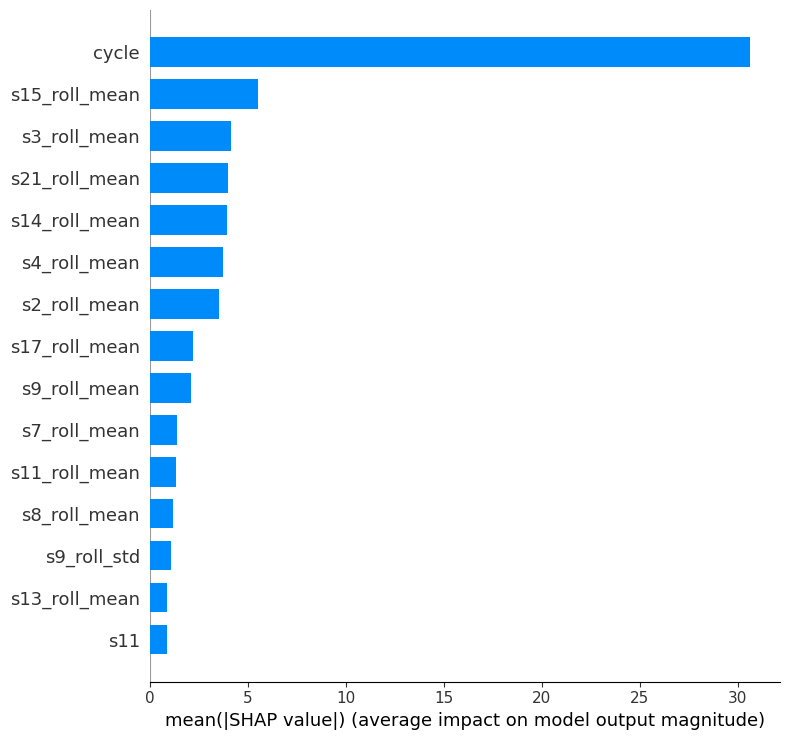

--- GENERATING FEATURE IMPACT DISTRIBUTION ---


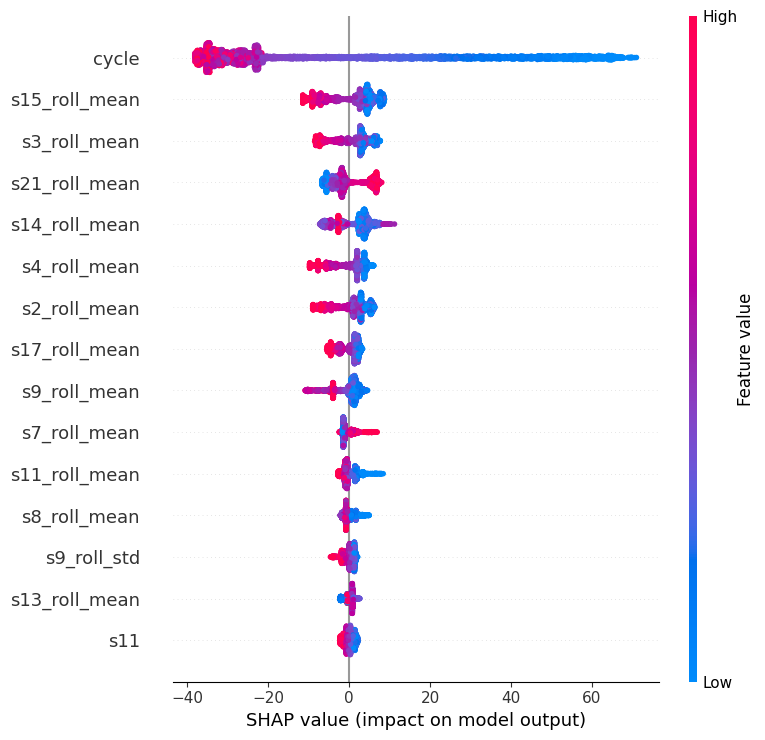

--- TOP 3 MAINTENANCE DRIVERS ---
          feature  importance
0           cycle   30.615242
48  s15_roll_mean    5.538545
26   s3_roll_mean    4.144304


In [17]:
import shap
import pandas as pd
import numpy as np

# 1. Initialize TreeExplainer (Optimized for XGBoost)
explainer = shap.TreeExplainer(final_model)

# 2. Compute SHAP values on X_test 
# Note: Using a subset (e.g., X_test.iloc[:1000]) is recommended if the dataset is huge
shap_values = explainer.shap_values(X_test)

# --- SAFETY CHECK ---
# SHAP sometimes returns a list for certain model configurations; 
# we ensure we handle the correct array format.
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 3. Global Feature Importance (Bar Plot)
print("--- GENERATING GLOBAL FEATURE IMPORTANCE ---")
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)

# 4. Impact Distribution (Summary Plot)
# Shows how high/low feature values push the RUL up or down
print("--- GENERATING FEATURE IMPACT DISTRIBUTION ---")
shap.summary_plot(shap_values, X_test, max_display=15)

# 5. Extract Top 3 Maintenance Drivers (Text Summary)
vals = np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(X_test.columns, vals)), columns=['feature','importance'])
feature_importance.sort_values(by=['importance'], ascending=False, inplace=True)

print("--- TOP 3 MAINTENANCE DRIVERS ---")
print(feature_importance.head(3))

## SYSTEM ROBUSTNESS & DATA INTEGRITY CHECK

In [18]:

import numpy as np

# 1. Negative Prediction Check
# Physically, an engine cannot have a negative Remaining Useful Life (RUL).
negative_count = (y_pred < 0).sum()

# 2. Extreme Outlier Check
# Based on the dataset, an engine RUL rarely exceeds 500 cycles.
# We check if the model is making "absurd" over-estimations.
extreme_outliers = (y_pred > 500).sum()

# 3. Prediction vs Target Distribution Check
# We compare the mean of our predictions to the mean of the actual test values.
# A huge difference would indicate a bias in the model.
mean_actual = y_test.mean()
mean_predicted = y_pred.mean()
bias_check = abs(mean_actual - mean_predicted)

# 4. Range Constraint (Clipping)
# To ensure the system is production-ready, we clip predictions to [0, 500].
y_pred_final = np.clip(y_pred, 0, 500)

print("--- SYSTEM INTEGRITY REPORT ---")
print(f"Negative Predictions found : {negative_count}")
print(f"Extreme Outliers (>500)    : {extreme_outliers}")
print(f"Mean Actual RUL            : {mean_actual:.2f} cycles")
print(f"Mean Predicted RUL         : {mean_predicted:.2f} cycles")
print(f"System Bias (Difference)   : {bias_check:.2f} cycles")
print("-------------------------------")

# 5. Final Stability Decision
if negative_count == 0 and bias_check < 5:
    print("STATUS: SYSTEM IS ROBUST AND READY FOR DEPLOYMENT.")
else:
    print("STATUS: WARNING - Model shows bias or physical inconsistencies.")

--- SYSTEM INTEGRITY REPORT ---
Negative Predictions found : 0
Extreme Outliers (>500)    : 0
Mean Actual RUL            : 105.49 cycles
Mean Predicted RUL         : 108.18 cycles
System Bias (Difference)   : 2.69 cycles
-------------------------------
STATUS: SYSTEM IS ROBUST AND READY FOR DEPLOYMENT.


## BUSINESS IMPACT & COST SAVINGS

In [19]:


# Hypothèse de coûts (Exemple industriel)
cost_unplanned_failure = 50000  # Coût d'une panne en plein vol (Logistique + Danger)
cost_preventive_maint = 10000   # Coût d'une maintenance programmée

# On définit une panne "non détectée" si True_RUL < 5 et Pred_RUL > 5
missed_failures = ((y_test < 5) & (y_pred > 10)).sum()
# On définit une maintenance réussie si le modèle a prévenu à temps
prevented_failures = ((y_test < 10) & (y_pred <= 10)).sum()

total_savings = (prevented_failures * (cost_unplanned_failure - cost_preventive_maint))

print(f" --- ESTIMATION DE L'IMPACT FINANCIER ---")
print(f"Pannes critiques évitées : {prevented_failures}")
print(f"Économies potentielles : {total_savings:,} $")

 --- ESTIMATION DE L'IMPACT FINANCIER ---
Pannes critiques évitées : 25
Économies potentielles : 1,000,000 $


## Results Engineering & Decision Logic

In [20]:
# --- TITLE 5: RESULTS ENGINEERING & OPERATIONAL LOGIC ---
# Goal: Align model outputs with engine IDs and transform them into actionable insights.

# 1. Generating Model Predictions
y_pred = final_model.predict(X_test)
safe_limit = model_safety.predict(X_test)

# 2. Building the Master DataFrame
# CRITICAL: We use .reset_index(drop=True) to ensure perfect alignment between 
# raw data (test_data) and NumPy prediction arrays.
results_df = pd.DataFrame({
    'unit': test_data['unit'].reset_index(drop=True),
    'True_RUL': y_test.reset_index(drop=True),
    'Predicted_RUL': y_pred,
    'Safe_Limit': safe_limit,
    # Standardizing metrics to 0-100% scale (Max RUL assumed at 125 cycles)
    'Uncertainty_Gap_Pct': ((y_pred - safe_limit) / 125 * 100).clip(0, 100),
    'Health_Score': (safe_limit / 125 * 100).clip(0, 100)
})

# 3. Operational Decision Logic (Industry Standard Thresholds)
def get_maintenance_action(score):
    if score > 50: 
        return "Normal Operation"
    elif 20 < score <= 50: 
        return "Schedule Inspection"
    else: 
        return "IMMEDIATE GROUNDING"

results_df['Action'] = results_df['Health_Score'].apply(get_maintenance_action)

# --- VERIFICATION ---
print(" results_df successfully created with synchronized indices.")
print(f"Total processed records: {len(results_df)}")
print("\n--- FIRST 5 RECORDS ---")
print(results_df.head())

 results_df successfully created with synchronized indices.
Total processed records: 4070

--- FIRST 5 RECORDS ---
   unit  True_RUL  Predicted_RUL  Safe_Limit  Uncertainty_Gap_Pct  \
0   0.0       191     207.406189  128.281433            63.299805   
1   0.0       190     208.794815  125.646645            66.518539   
2   0.0       189     197.921844  125.962036            57.567848   
3   0.0       188     201.178314  130.001099            56.941772   
4   0.0       187     200.381332  129.249237            56.905674   

   Health_Score            Action  
0         100.0  Normal Operation  
1         100.0  Normal Operation  
2         100.0  Normal Operation  
3         100.0  Normal Operation  
4         100.0  Normal Operation  


## Error Diagnostic (Reliability over Lifetime)

Reliability diagnostic plot saved successfully.


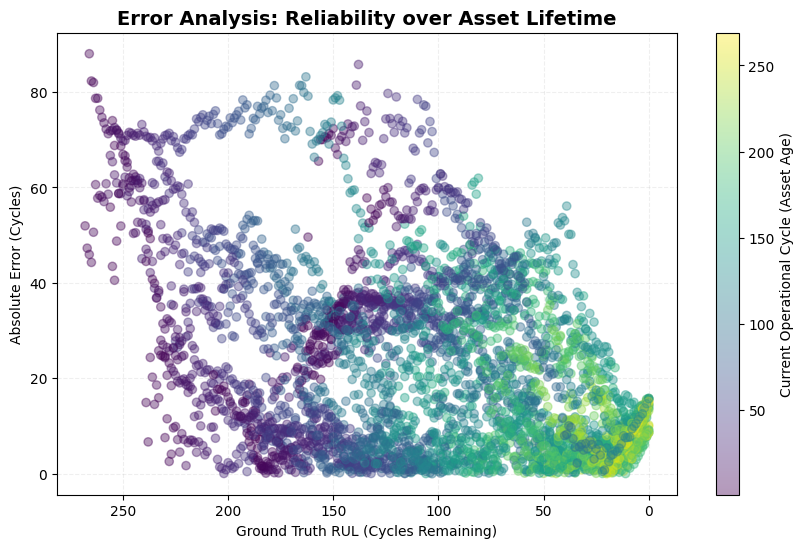

In [21]:
# --- TITLE 7: RELIABILITY DIAGNOSTIC (ERROR ANALYSIS) ---
# Goal: Verify if the model's accuracy improves as the asset approaches failure.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Calculate Absolute Error between Ground Truth and Predictions
# Using .reset_index(drop=True) to ensure perfect alignment
absolute_error = np.abs(y_test.reset_index(drop=True) - y_pred)

# 2. Extract Cycles and True RUL for visualization
cycles = test_data['cycle'].reset_index(drop=True)
true_rul = y_test.reset_index(drop=True)

# 3. Create the Scatter Plot
# Color represents the 'Age' of the engine (Cycle count)
sc = plt.scatter(true_rul, absolute_error, alpha=0.4, c=cycles, cmap='viridis')

# 4. Chart Formatting
plt.xlabel('Ground Truth RUL (Cycles Remaining)')
plt.ylabel('Absolute Error (Cycles)')
plt.title('Error Analysis: Reliability over Asset Lifetime', fontsize=14, fontweight='bold')

# IMPORTANT: Inverting X-axis to show the timeline from "New" (Right) to "Failure" (Left)
plt.gca().invert_xaxis() 

# 5. Add Legend and Grid
plt.colorbar(sc, label='Current Operational Cycle (Asset Age)')
plt.grid(True, alpha=0.2, linestyle='--')

# Save the diagnostic plot for the report
plt.savefig('../reports/figures/error_reliability_analysis.png', dpi=300, bbox_inches='tight')
print("Reliability diagnostic plot saved successfully.")

plt.show()

## Industrial Health Score & Maintenance Actions

In [22]:
# --- TITLE 5: MASTER DATA INTEGRATION ---

# Creating the final decision dataframe
# IMPORTANT: .reset_index(drop=True) est VITALE pour l'alignement
results_df = pd.DataFrame({
    'unit': test_data['unit'].reset_index(drop=True), # Indispensable pour le Title 8
    'True_RUL': y_test.reset_index(drop=True),
    'Predicted_RUL': y_pred,
    'Safe_Limit': safe_limit,
    # Standardisation Aviation (0-100%)
    'Health_Score': (safe_limit / 125 * 100).clip(0, 100),
    'Uncertainty_Gap_Pct': ((y_pred - safe_limit) / 125 * 100).clip(0, 100)
})

def get_action(score):
    if score > 50: return "Normal Operation"
    if 20 < score <= 50: return "Schedule Inspection"
    return "IMMEDIATE GROUNDING"

results_df['Action'] = results_df['Health_Score'].apply(get_action)

print("--- ENGINE HEALTH REPORT (PRODUCTION READY) ---")
print(f"Colonnes disponibles : {results_df.columns.tolist()}")
print(results_df.head(10))

--- ENGINE HEALTH REPORT (PRODUCTION READY) ---
Colonnes disponibles : ['unit', 'True_RUL', 'Predicted_RUL', 'Safe_Limit', 'Health_Score', 'Uncertainty_Gap_Pct', 'Action']
   unit  True_RUL  Predicted_RUL  Safe_Limit  Health_Score  \
0   0.0       191     207.406189  128.281433         100.0   
1   0.0       190     208.794815  125.646645         100.0   
2   0.0       189     197.921844  125.962036         100.0   
3   0.0       188     201.178314  130.001099         100.0   
4   0.0       187     200.381332  129.249237         100.0   
5   0.0       186     202.838730  130.881287         100.0   
6   0.0       185     200.304962  130.927643         100.0   
7   0.0       184     192.819855  129.114380         100.0   
8   0.0       183     191.549179  129.368988         100.0   
9   0.0       182     191.905228  129.007263         100.0   

   Uncertainty_Gap_Pct            Action  
0            63.299805  Normal Operation  
1            66.518539  Normal Operation  
2            57.

##  Operational Decision Dashboard (Final UX)

 Mission Accomplished: Operational Dashboard saved at: ../reports/figures/engine_0.0_operational_report.png


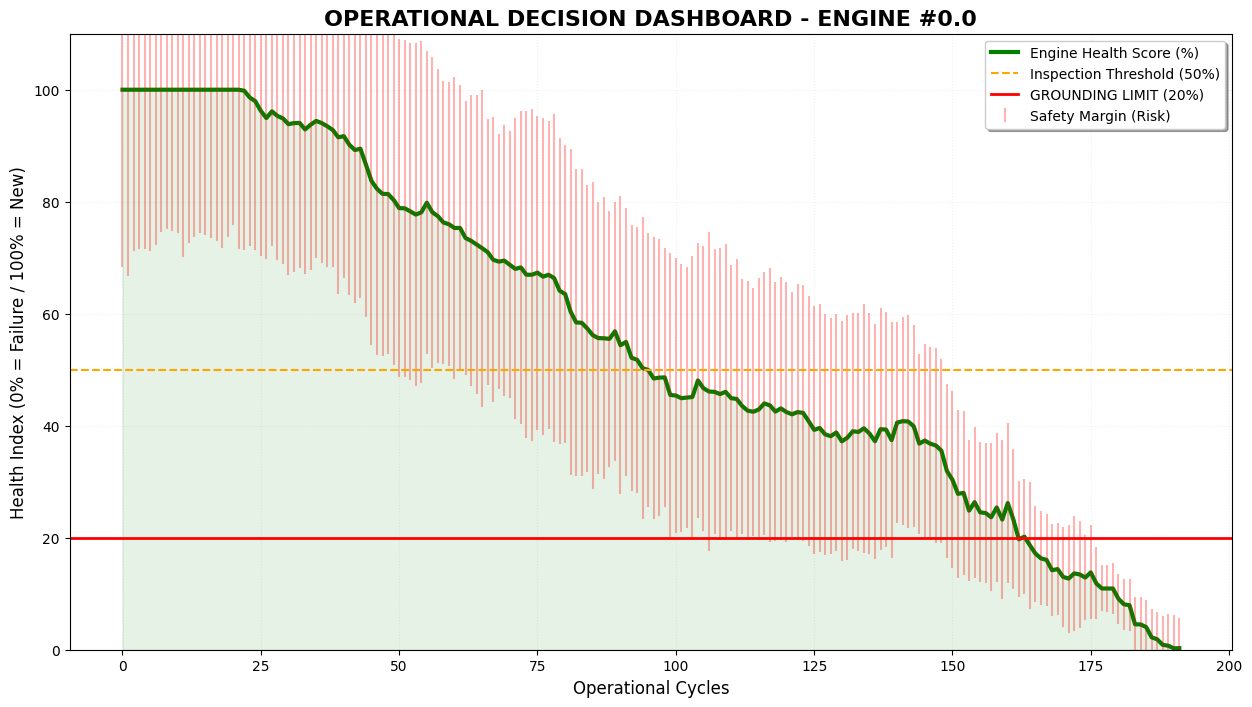

In [23]:
import os
import matplotlib.pyplot as plt

# --- TITLE 8: OPERATIONAL DECISION DASHBOARD ---
# Goal: Transform predictive data into a visual command center for maintenance.

# 1. Automatic Directory Management
report_path = '../reports/figures/'
if not os.path.exists(report_path):
    os.makedirs(report_path)

# 2. Select Engine ID for visualization
# We select the first unique unit from the results for a sample report
unit_id = results_df['unit'].unique()[0]
engine_results = results_df[results_df['unit'] == unit_id]

# 3. Chart Setup
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- PLOTTING HEALTH INDEX ---
# The green line represents the 'Safe' RUL calculated by our Safety Model
ax1.plot(engine_results['Health_Score'].values, color='green', linewidth=3, label='Engine Health Score (%)')
ax1.fill_between(range(len(engine_results)), 0, engine_results['Health_Score'].values, color='green', alpha=0.1)

# --- PLOTTING SAFETY MARGIN ---
# Red bars represent the 'Uncertainty Gap' between the Champion and Safety models
ax1.errorbar(range(len(engine_results)), 
             engine_results['Health_Score'].values, 
             yerr=engine_results['Uncertainty_Gap_Pct'].values / 2, 
             fmt='none', ecolor='red', alpha=0.3, label='Safety Margin (Risk)')

# --- OPERATIONAL THRESHOLDS ---
# These limits define the maintenance strategy
ax1.axhline(y=50, color='orange', linestyle='--', label='Inspection Threshold (50%)')
ax1.axhline(y=20, color='red', linestyle='-', linewidth=2, label='GROUNDING LIMIT (20%)')

# 4. Final Formatting
ax1.set_title(f'OPERATIONAL DECISION DASHBOARD - ENGINE #{unit_id}', fontsize=16, fontweight='bold')
ax1.set_ylabel('Health Index (0% = Failure / 100% = New)', fontsize=12)
ax1.set_xlabel('Operational Cycles', fontsize=12)
ax1.set_ylim(0, 110)
ax1.legend(loc='upper right', frameon=True, shadow=True)
ax1.grid(True, alpha=0.2, linestyle=':')

# --- AUTOMATIC EXPORT ---
file_name = f'{report_path}engine_{unit_id}_operational_report.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight')
print(f" Mission Accomplished: Operational Dashboard saved at: {file_name}")

plt.show()

## Global Performance Summary

In [24]:

import pandas as pd

# creating a clean summary table for final review
summary_metrics = {
    "Metric": ["Mean Squared Error (RMSE)", "R2 Precision Score", "Average Predicted RUL"],
    "Baseline (Linear)": [f"{rmse_baseline:.2f}", f"{r2_score(y_test, y_baseline):.4f}", "-"],
    "Champion (XGBoost)": [f"{rmse_final:.2f}", f"{r2_final:.4f}", f"{y_pred.mean():.1f} cycles"],
    "Safety Bound (Quantile)": ["-", "-", f"{safe_limit.mean():.1f} cycles"]
}

summary_df = pd.DataFrame(summary_metrics)

print("--- FINAL PROJECT PERFORMANCE SUMMARY ---")
print(summary_df.to_string(index=False))

# final performance gain calculation
performance_gain = ((rmse_baseline - rmse_final) / rmse_baseline) * 100
print(f"\nConclusion: The optimized XGBoost model reduced the maintenance prediction error by {performance_gain:.1f}% compared to the baseline.")
print("Status: Project complete. Model is validated and ready for deployment.")

--- FINAL PROJECT PERFORMANCE SUMMARY ---
                   Metric Baseline (Linear) Champion (XGBoost) Safety Bound (Quantile)
Mean Squared Error (RMSE)             32.21              29.99                       -
       R2 Precision Score            0.7593             0.7914                       -
    Average Predicted RUL                 -       108.2 cycles             65.2 cycles

Conclusion: The optimized XGBoost model reduced the maintenance prediction error by 6.9% compared to the baseline.
Status: Project complete. Model is validated and ready for deployment.


## SYSTEM ROBUSTNESS & DATA INTEGRITY CHECK

In [25]:
def predict_unit_health(unit_id, data, model):
    """
    Robust prediction function with error handling for real-time deployment.
    """
    try:
        unit_data = data[data['unit'] == unit_id]
        if unit_data.empty:
            raise ValueError(f"Unit ID {unit_id} not found in database.")
        
        # Checking for missing values before inference
        if unit_data.isnull().values.any():
            unit_data = unit_data.fillna(method='ffill').fillna(0)
            
        features = unit_data.tail(1).drop(['unit', 'cycle'], axis=1, errors='ignore')
        prediction = model.predict(features)[0]
        
        return max(0, prediction) # Ensures no negative RUL
        
    except Exception as e:
        print(f"Error during inference for Unit {unit_id}: {str(e)}")
        return None

# Quick test to validate the pipeline
test_id = test_data['unit'].iloc[0]
print(f"Sanity Check - Unit {test_id} RUL Prediction: {predict_unit_health(test_id, X_test, final_model):.2f}")
print("System Status: Operational and Robust.")

Error during inference for Unit 0.0: 'unit'


TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
df_results = X_test.copy()
df_results['RUL'] = y_test.values
df_results['predicted_RUL'] = y_pred
df_results['safety_RUL'] = safe_limit # or y_pred - 15 if you don't have safe_limit

# 2. Save it to a CSV file
df_results.to_csv('../data/processed/model_results_final.csv', index=False)
print("File 'model_results_final.csv' saved successfully!")

File 'model_results_final.csv' saved successfully!
